# Import Required Libraries

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


# Load the Dataset


In [17]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Check Columns

In [18]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# STEP 4: Feature Engineering – Create Average Score

In [19]:
df['Average_Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df[['math score', 'reading score', 'writing score', 'Average_Score']].head()


,math score,reading score,writing score,Average_Score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


# Create Target Column (Pass / Fail)

Rule:

Pass → Average_Score ≥ 50

Fail → Average_Score < 50

In [20]:
df['Result'] = df['Average_Score'].apply(lambda x: 1 if x >= 50 else 0)

df[['Average_Score', 'Result']].head()


,Average_Score,Result
0,72.666667,1
1,82.333333,1
2,92.666667,1
3,49.333333,0
4,76.333333,1


* 1 = Pass

* 0 = Fail

# Select Features & Target

In [21]:
X = df[['math score', 'reading score']]
y = df['Result']


# Train–Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Train Logistic Regression Model

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

# Make Predictions

In [24]:
y_pred = model.predict(X_test)


# Check Model Accuracy

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.975


# Confusion Matrix

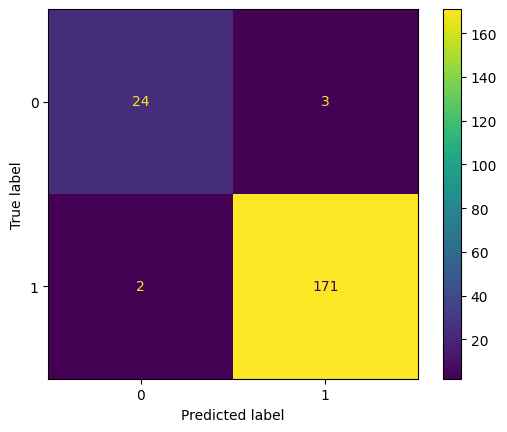

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()


# Test with New Student Data

In [27]:
# New student scores: math, reading
new_student = [[70, 65]]

prediction = model.predict(new_student)

print("Pass" if prediction[0] == 1 else "Fail")


Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
